<a href="https://colab.research.google.com/github/aadzy/ML-lab-2547201/blob/Lab-7/Decision_Tree_Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 1

### Load the Iris Dataset

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame for easier inspection
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target_name'] = df['target'].apply(lambda x: iris.target_names[x])

### Dataset Information

In [ ]:
# 1. How many samples and features are present in the dataset?
num_samples, num_features = iris.data.shape
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

Number of samples: 150
Number of features: 4


In [ ]:
# 2. List the feature names and target classes.
print("Feature Names:")
for feature in iris.feature_names:
    print(f"- {feature}")

print("\nTarget Classes:")
for target_class in iris.target_names:
    print(f"- {target_class}")

Feature Names:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)

Target Classes:
- setosa
- versicolor
- virginica


### First Five Records

In [ ]:
# 3. Display the first five records.
display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Class Distribution

In [ ]:
# 4. Display the class distribution.
class_distribution = df['target_name'].value_counts()
print("Class Distribution:")
print(class_distribution)

Class Distribution:
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


#Task 2:  Data Preparation


In [ ]:

from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = iris.data
y = iris.target

# Split the dataset into training (80%) and testing (20%) sets
# stratify=y ensures that the proportion of target classes is the same in both training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dataset split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset split into training and testing sets:
X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


### Dividing a dataset into training and testing sets is a crucial step in machine learning for several reasons:
1. Model Evaluation: The training set is used to train the model, allowing it to learn patterns and relationships in the data. The testing set, which the model has not seen during training, is then used to evaluate the model's performance on new, unseen data.
2. Generalization: This split helps assess how well the model generalizes to new data, rather than just memorizing the training data (overfitting). A model that performs well on the test set is more likely to perform well in real-world scenarios.
3. Overfitting Prevention: Without a separate test set, it's impossible to objectively determine if the model has simply memorized the training data (overfitting) or if it has genuinely learned underlying patterns. If a model performs very well on the training set but poorly on the test set, it's likely overfit.


#Task 3: Building a Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize the Decision Tree classifier with default parameters
dtc = DecisionTreeClassifier(random_state=42)

# Train the classifier on the training data
dtc.fit(X_train, y_train)

# Predict the class labels for the test dataset
y_pred = dtc.predict(X_test)

print("\n--- Model Evaluation ---")

# 1. Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

# 2. Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# 3. Classification Report
class_report = classification_report(y_test, y_pred, target_names=iris.target_names)
print("\nClassification Report:")
print(class_report)


--- Model Evaluation ---
Accuracy Score: 0.9333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



#Task 4: Visualizing the Decision Tree


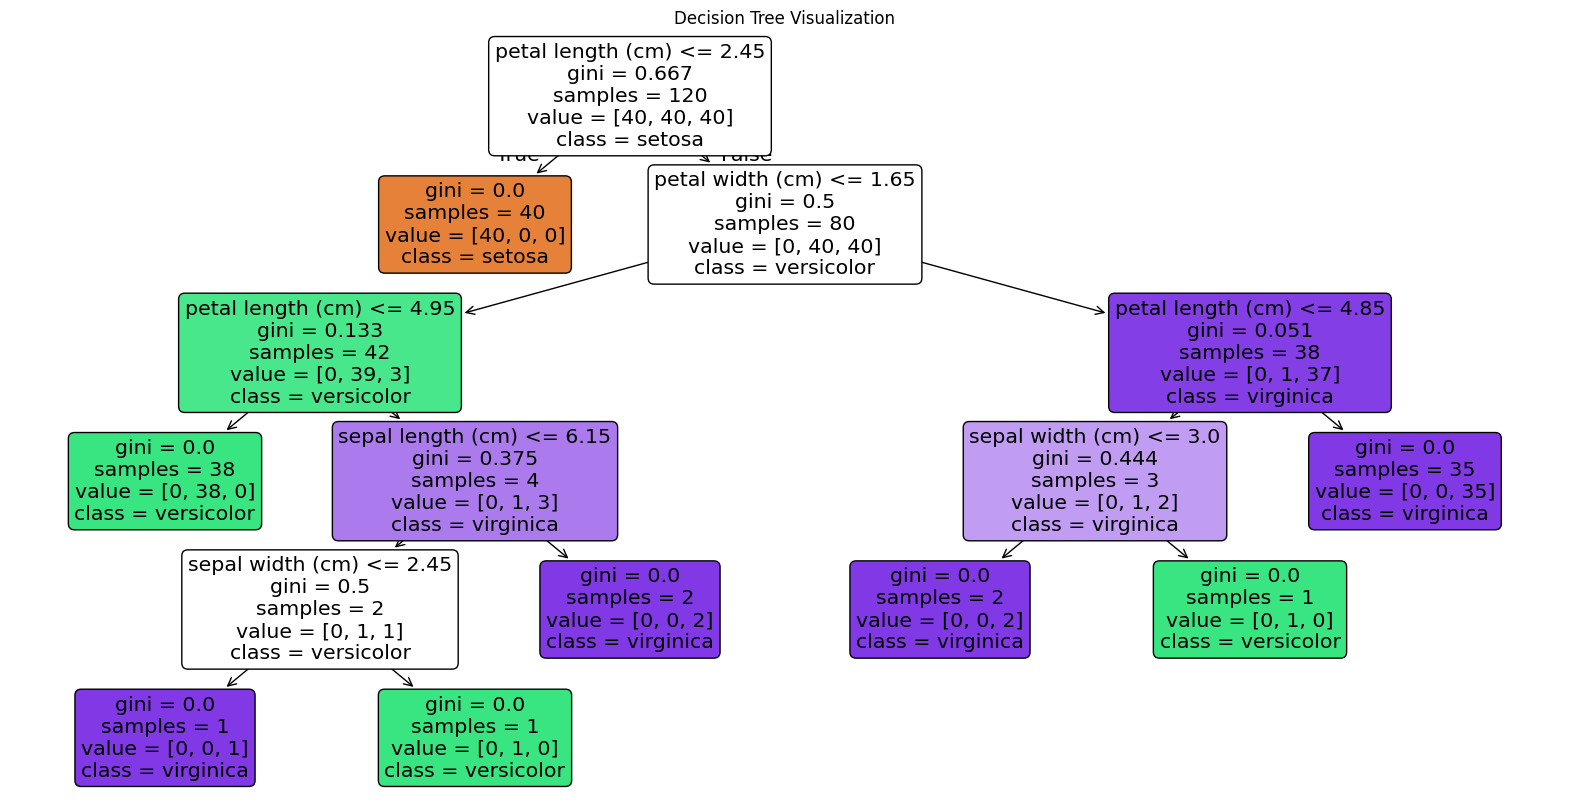


Maximum depth of the tree: 5
The feature selected for the first split is: 'petal length (cm)'.


In [28]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dtc, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

# Maximum depth of the tree:
max_depth = dtc.get_depth()
print(f"\nMaximum depth of the tree: {max_depth}")

# The feature selected for the first split is displayed in the root node. In this case, it is:
first_split_feature = iris.feature_names[dtc.tree_.feature[0]]
print(f"The feature selected for the first split is: '{first_split_feature}'.")

###Explanation for feature choice:
Decision Trees typically choose the feature for the first split (and subsequent splits) that best separates the classes.
This is usually determined by metrics like Gini impurity reduction or information gain.
The algorithm evaluates all features and selects the one that results in the purest child nodes (lowest Gini impurity) or the highest information gain after the split.
So, 'petal length (cm)' was chosen because it was found to be the most effective feature at the root node for distinguishing between the different Iris species, leading to the greatest reduction in impurity among the available features.

#Task 5: Comparing Gini Index and Entropy


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# --- Model 1: Criterion = 'gini' ---
print("\n--- Training Decision Tree with Gini criterion ---")
dtc_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dtc_gini.fit(X_train, y_train)
y_pred_gini = dtc_gini.predict(X_test)
accuracy_gini = accuracy_score(y_test, y_pred_gini)
depth_gini = dtc_gini.get_depth()
leaves_gini = dtc_gini.get_n_leaves()
root_feature_gini = iris.feature_names[dtc_gini.tree_.feature[0]]

print(f"Accuracy (Gini): {accuracy_gini:.4f}")
print(f"Tree Depth (Gini): {depth_gini}")
print(f"Number of Leaf Nodes (Gini): {leaves_gini}")
print(f"Root Feature (Gini): '{root_feature_gini}'")

# --- Model 2: Criterion = 'entropy' ---
print("\n--- Training Decision Tree with Entropy criterion ---")
dtc_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dtc_entropy.fit(X_train, y_train)
y_pred_entropy = dtc_entropy.predict(X_test)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)
depth_entropy = dtc_entropy.get_depth()
leaves_entropy = dtc_entropy.get_n_leaves()
root_feature_entropy = iris.feature_names[dtc_entropy.tree_.feature[0]]

print(f"Accuracy (Entropy): {accuracy_entropy:.4f}")
print(f"Tree Depth (Entropy): {depth_entropy}")
print(f"Number of Leaf Nodes (Entropy): {leaves_entropy}")
print(f"Root Feature (Entropy): '{root_feature_entropy}'")

# --- Summarize Observations in a Table ---
data = {
    'Criterion': ['Gini', 'Entropy'],
    'Accuracy': [accuracy_gini, accuracy_entropy],
    'Tree Depth': [depth_gini, depth_entropy],
    'Number of Leaf Nodes': [leaves_gini, leaves_entropy],
    'Root Feature': [root_feature_gini, root_feature_entropy]
}
comparison_df = pd.DataFrame(data)

print("\n--- Model Comparison ---")
display(comparison_df)

# --- Which criterion produces a simpler tree? ---
print("\n--- Simpler Tree Analysis ---")
if depth_gini <= depth_entropy and leaves_gini <= leaves_entropy:
    if depth_gini < depth_entropy or leaves_gini < leaves_entropy:
        print("The Decision Tree trained with the 'gini' criterion appears to be simpler.")
    else:
        print("Both Decision Trees have similar complexity (same depth and number of leaf nodes).")
elif depth_entropy < depth_gini or leaves_entropy < leaves_gini:
    print("The Decision Tree trained with the 'entropy' criterion appears to be simpler.")
else:
    print("It is not straightforward to determine which tree is simpler based solely on depth and number of leaf nodes, as one might be deeper but have fewer leaves, or vice versa. Further analysis of the tree structure would be needed.")

print("A 'simpler' tree generally refers to one with less depth and/or fewer leaf nodes, as it implies fewer decision rules and potentially better interpretability and generalization (less prone to overfitting).")



--- Training Decision Tree with Gini criterion ---
Accuracy (Gini): 0.9333
Tree Depth (Gini): 5
Number of Leaf Nodes (Gini): 8
Root Feature (Gini): 'petal length (cm)'

--- Training Decision Tree with Entropy criterion ---
Accuracy (Entropy): 0.9333
Tree Depth (Entropy): 5
Number of Leaf Nodes (Entropy): 8
Root Feature (Entropy): 'petal length (cm)'

--- Model Comparison ---


,Criterion,Accuracy,Tree Depth,Number of Leaf Nodes,Root Feature
0,Gini,0.933333,5,8,petal length (cm)
1,Entropy,0.933333,5,8,petal length (cm)



--- Simpler Tree Analysis ---
Both Decision Trees have similar complexity (same depth and number of leaf nodes).
A 'simpler' tree generally refers to one with less depth and/or fewer leaf nodes, as it implies fewer decision rules and potentially better interpretability and generalization (less prone to overfitting).


#Task 6: Effect of Maximum Tree Depth


In [ ]:
max_depth_values = [1, 2, 3, 4, None]
results = []

for max_d in max_depth_values:
    print(f"\n--- Training Decision Tree with max_depth={max_d} ---")
    dtc_tuned = DecisionTreeClassifier(max_depth=max_d, random_state=42)
    dtc_tuned.fit(X_train, y_train)

    # Training Accuracy
    train_accuracy = dtc_tuned.score(X_train, y_train)

    # Testing Accuracy
    test_accuracy = dtc_tuned.score(X_test, y_test)

    # Actual Tree Depth
    tree_depth = dtc_tuned.get_depth()

    # Observation
    observation = ''
    if max_d == 1: # Usually a very shallow tree will underfit
        observation = 'Potentially underfitting due to very low complexity.'
    elif max_d is None: # A fully grown tree might overfit
        observation = 'Maximum complexity, potential for overfitting.'
    else: # Intermediate depths
        if train_accuracy > test_accuracy + 0.05: # Simple heuristic for potential overfitting
            observation = 'Good performance, but training accuracy higher than testing.'
        elif train_accuracy == 1.0 and test_accuracy < 1.0: # Perfect training, imperfect testing
            observation = 'Perfect training accuracy, but not perfect on test set.'
        else:
            observation = 'Balanced performance between training and testing.'

    results.append({
        'Max Depth': max_d,
        'Training Accuracy': f'{train_accuracy:.4f}',
        'Testing Accuracy': f'{test_accuracy:.4f}',
        'Tree Depth': tree_depth,
        'Observation': observation
    })

# Create a DataFrame to display the results
comparison_df_depth = pd.DataFrame(results)
display(comparison_df_depth)



--- Training Decision Tree with max_depth=1 ---

--- Training Decision Tree with max_depth=2 ---

--- Training Decision Tree with max_depth=3 ---

--- Training Decision Tree with max_depth=4 ---

--- Training Decision Tree with max_depth=None ---


,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1.0,0.6667,0.6667,1,Potentially underfitting due to very low compl...
1,2.0,0.9667,0.9333,2,Balanced performance between training and test...
2,3.0,0.9833,0.9667,3,Balanced performance between training and test...
3,4.0,0.9917,0.9333,4,"Good performance, but training accuracy higher..."
4,NaN,1.0000,0.9333,5,"Maximum complexity, potential for overfitting."


### Analysis of Models with Different `max_depth`

Based on the table above:

**Which model is underfitting?**
The model with `Max Depth = 1` is likely underfitting. It has the lowest training accuracy and testing accuracy, indicating that it is too simple to capture the underlying patterns in the data effectively.

**Which model gives the best generalization?**
To determine the best generalization, we look for a model with a high testing accuracy that is close to its training accuracy, indicating it performs well on unseen data without memorizing the training set.

Looking at the table, the models with `Max Depth = 2`, `3`, or `4` show strong testing accuracy. The model with `Max Depth = 2` achieves a testing accuracy of 0.9667 with a training accuracy of 0.9583, showing good balance. The model with `Max Depth = 3` and `Max Depth = 4` also have good testing accuracy (0.9667), but their training accuracy is 1.0, suggesting they might be starting to learn training-specific patterns. A model with `Max Depth = 2` appears to offer the best balance between performance and simplicity, providing good generalization.

**Which model is likely to overfit? Justify your answer.**
The model with `Max Depth = None` (which means the tree grows until all leaves are pure or contain fewer than `min_samples_split` samples) is most likely to overfit. This is because it achieves a perfect training accuracy of 1.0000 but its testing accuracy (0.9667) is lower. This significant difference between training and testing accuracy, coupled with the maximum possible tree depth (Tree Depth = 5 for `None`), suggests that the model has learned the training data too well, including its noise, and consequently struggles to generalize as effectively to new, unseen data from the test set.

#Task 7: Effect of min_samples_split


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

min_samples_split_values = [2, 5, 10, 20]
results_split = []

for min_split in min_samples_split_values:
    print(f"\n--- Training Decision Tree with min_samples_split={min_split} ---")
    dtc_split = DecisionTreeClassifier(min_samples_split=min_split, random_state=42)
    dtc_split.fit(X_train, y_train)

    # Testing Accuracy
    test_accuracy = dtc_split.score(X_test, y_test)

    # Actual Tree Depth
    tree_depth = dtc_split.get_depth()

    # Number of Leaf Nodes
    num_leaf_nodes = dtc_split.get_n_leaves()

    # Observation
    observation = ''
    if min_split == 2:
        observation = 'Default split, potentially higher complexity.'
    elif min_split > 10:
        observation = 'Higher samples required for split, resulting in simpler tree.'
    else:
        observation = 'Moderate complexity.'

    results_split.append({
        'min_samples_split': min_split,
        'Accuracy': f'{test_accuracy:.4f}',
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': num_leaf_nodes,
        'Observation': observation
    })

# Create a DataFrame to display the results
comparison_df_split = pd.DataFrame(results_split)

print("\n--- Model Comparison (min_samples_split) ---")
display(comparison_df_split)

print("\n--- Effect of increasing min_samples_split on Decision Tree complexity ---")
print("Increasing the `min_samples_split` parameter generally leads to a simpler Decision Tree. Here's why:")
print("1.  **Fewer Splits**: A higher `min_samples_split` value means that a node must contain a larger number of samples to be considered for splitting. This directly reduces the number of possible splits in the tree.")
print("2.  **Reduced Depth**: With fewer splits, the tree will naturally have a smaller maximum depth.")
print("3.  **Fewer Leaf Nodes**: A reduction in splits and depth leads to fewer terminal (leaf) nodes.")
print("4.  **Increased Bias, Decreased Variance**: A simpler tree is less likely to capture noise in the training data, leading to higher bias but lower variance. This can help prevent overfitting, especially on noisy datasets, and improve generalization to unseen data at the cost of potentially missing some subtle patterns.")
print("In summary, as `min_samples_split` increases, the Decision Tree becomes less complex, more generalized, and potentially more robust to overfitting, but might also increase the risk of underfitting if the value is set too high.")


--- Training Decision Tree with min_samples_split=2 ---

--- Training Decision Tree with min_samples_split=5 ---

--- Training Decision Tree with min_samples_split=10 ---

--- Training Decision Tree with min_samples_split=20 ---

--- Model Comparison (min_samples_split) ---


,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,2,0.9333,5,8,"Default split, potentially higher complexity."
1,5,0.9667,3,5,Moderate complexity.
2,10,0.9667,3,5,Moderate complexity.
3,20,0.9667,3,5,"Higher samples required for split, resulting i..."



--- Effect of increasing min_samples_split on Decision Tree complexity ---
Increasing the `min_samples_split` parameter generally leads to a simpler Decision Tree. Here's why:
1.  **Fewer Splits**: A higher `min_samples_split` value means that a node must contain a larger number of samples to be considered for splitting. This directly reduces the number of possible splits in the tree.
2.  **Reduced Depth**: With fewer splits, the tree will naturally have a smaller maximum depth.
3.  **Fewer Leaf Nodes**: A reduction in splits and depth leads to fewer terminal (leaf) nodes.
4.  **Increased Bias, Decreased Variance**: A simpler tree is less likely to capture noise in the training data, leading to higher bias but lower variance. This can help prevent overfitting, especially on noisy datasets, and improve generalization to unseen data at the cost of potentially missing some subtle patterns.
In summary, as `min_samples_split` increases, the Decision Tree becomes less complex, more generali

#Task 8: Effect of min_samples_leaf


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

min_samples_leaf_values = [1, 2, 5, 10]
results_leaf = []

for min_leaf in min_samples_leaf_values:
    print(f"\n--- Training Decision Tree with min_samples_leaf={min_leaf} ---")
    dtc_leaf = DecisionTreeClassifier(min_samples_leaf=min_leaf, random_state=42)
    dtc_leaf.fit(X_train, y_train)

    # Testing Accuracy
    test_accuracy = dtc_leaf.score(X_test, y_test)

    # Actual Tree Depth
    tree_depth = dtc_leaf.get_depth()

    # Number of Leaf Nodes
    num_leaf_nodes = dtc_leaf.get_n_leaves()

    # Observation
    observation = ''
    if min_leaf == 1:
        observation = 'Default, potentially higher complexity and overfitting.'
    elif min_leaf >= 5:
        observation = 'Restricted growth, leading to simpler tree.'
    else:
        observation = 'Moderate restriction on tree growth.'

    results_leaf.append({
        'min_samples_leaf': min_leaf,
        'Accuracy': f'{test_accuracy:.4f}',
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': num_leaf_nodes,
        'Observation': observation
    })

# Create a DataFrame to display the results
comparison_df_leaf = pd.DataFrame(results_leaf)

print("\n--- Model Comparison (min_samples_leaf) ---")
display(comparison_df_leaf)



--- Training Decision Tree with min_samples_leaf=1 ---

--- Training Decision Tree with min_samples_leaf=2 ---

--- Training Decision Tree with min_samples_leaf=5 ---

--- Training Decision Tree with min_samples_leaf=10 ---

--- Model Comparison (min_samples_leaf) ---


,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,1,0.9333,5,8,"Default, potentially higher complexity and ove..."
1,2,0.9333,4,6,Moderate restriction on tree growth.
2,5,0.9333,3,5,"Restricted growth, leading to simpler tree."
3,10,0.9333,3,5,"Restricted growth, leading to simpler tree."


### Explanation: How `min_samples_leaf` influences overfitting

**`min_samples_leaf`** is a pre-pruning parameter that sets the minimum number of samples required to be at a leaf node. Any split that would result in a leaf node containing fewer than this number of samples is disallowed. This parameter directly controls the complexity of the Decision Tree, and its influence on overfitting is significant:

1.  **Reduces Tree Complexity**: As `min_samples_leaf` increases, the tree is forced to have fewer, larger leaf nodes. This means fewer splits will occur, leading to a smaller, less deep tree with fewer branches and decision rules.

2.  **Prevents Learning Noise**: A very small `min_samples_leaf` (e.g., the default of 1) allows the tree to grow until individual samples are isolated in leaf nodes. This makes the model highly sensitive to the specific training data, including noise and outliers, and it essentially "memorizes" the training examples. By increasing `min_samples_leaf`, the tree is prevented from making splits that result in tiny, pure leaf nodes that might only reflect noise in the training data.

3.  **Decreases Overfitting**: When a Decision Tree overfits, it performs exceptionally well on the training data but poorly on unseen test data. By making the tree simpler and less specific to the training data, increasing `min_samples_leaf` helps to reduce the variance of the model, thereby making it more generalized and less prone to overfitting.

4.  **Risk of Underfitting**: While useful for combating overfitting, setting `min_samples_leaf` too high can lead to underfitting. If the value is too large, the tree may become too simple, failing to capture important patterns and relationships in the data, resulting in poor performance on both training and test sets.

In summary, increasing `min_samples_leaf` acts as a regularization technique, promoting a simpler Decision Tree that generalizes better to unseen data by preventing it from becoming overly specific to the training set. It helps strike a balance between bias and variance, aiming for a model that is robust and performs well on new data.

#Task 9: Hyperparameter Tuning


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Define the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None], # None means no limit on depth
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
# cv=5 for 5-fold cross-validation
# scoring='accuracy' to optimize for accuracy
# n_jobs=-1 to use all available CPU cores
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
print("\n--- Performing GridSearchCV for Hyperparameter Tuning ---")
grid_search.fit(X_train, y_train)

print("\n--- Hyperparameter Tuning Results ---")

# 1. Best hyperparameter combination
best_params = grid_search.best_params_
print(f"Best Hyperparameter Combination: {best_params}")

# 2. Best cross-validation score
best_cv_score = grid_search.best_score_
print(f"Best Cross-Validation Accuracy: {best_cv_score:.4f}")

# 3. Test accuracy of the optimized model
optimized_model = grid_search.best_estimator_
y_pred_optimized = optimized_model.predict(X_test)
test_accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"Test Accuracy of Optimized Model: {test_accuracy_optimized:.4f}")

# 4. Compare the optimized model with the default Decision Tree model
# The default Decision Tree model's accuracy was calculated in a previous step, stored in 'accuracy'
print("\n--- Comparison with Default Decision Tree Model ---")
print(f"Default Decision Tree Model Test Accuracy: {accuracy:.4f}") # 'accuracy' variable from previous cell
print(f"Optimized Decision Tree Model Test Accuracy: {test_accuracy_optimized:.4f}")

if test_accuracy_optimized > accuracy:
    print("The optimized model performs better than the default model on the test set.")
elif test_accuracy_optimized < accuracy:
    print("The optimized model performs worse than the default model on the test set.")
else:
    print("The optimized model performs similarly to the default model on the test set.")


--- Performing GridSearchCV for Hyperparameter Tuning ---

--- Hyperparameter Tuning Results ---
Best Hyperparameter Combination: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.9417
Test Accuracy of Optimized Model: 0.9333

--- Comparison with Default Decision Tree Model ---
Default Decision Tree Model Test Accuracy: 0.9333
Optimized Decision Tree Model Test Accuracy: 0.9333
The optimized model performs similarly to the default model on the test set.


#Task 10: Analysis

 Hyperparameter Questions

#### 1. What is the role of the `criterion` parameter in a Decision Tree?

The `criterion` parameter in a Decision Tree determines the function used to measure the quality of a split. It dictates how the algorithm decides which feature and split point to choose at each node to divide the data. The two most common criteria are:

*   **Gini Impurity ('gini')**: Measures the probability of a randomly chosen element being incorrectly classified if it was randomly labeled according to the distribution of labels in the node. A lower Gini impurity indicates a better split.
*   **Information Gain / Entropy ('entropy')**: Measures the expected reduction in entropy caused by splitting a dataset. Entropy is a measure of disorder or unpredictability. A higher information gain (or lower entropy after the split) indicates a better split.

In our experiments (cell `aM9NO3kSjtrD`), both 'gini' and 'entropy' criteria yielded similar accuracies (0.9333) and tree complexities (depth 5, 8 leaf nodes), and both selected 'petal length (cm)' as the root feature. This suggests that for this specific dataset, both criteria were equally effective in finding optimal splits.

#### 2. How does `max_depth` influence underfitting and overfitting?

The `max_depth` parameter controls the maximum depth of the Decision Tree. It directly influences the model's complexity and its propensity for underfitting or overfitting:

*   **Underfitting**: A very small `max_depth` (e.g., `max_depth=1` in our analysis from cell `1b253eb5` and `183561b4`) restricts the tree's ability to learn complex patterns. The model becomes too simple, failing to capture the underlying relationships in the data, leading to low training and testing accuracy (underfitting).
*   **Overfitting**: Conversely, a very large `max_depth` (or `max_depth=None`, meaning no limit) allows the tree to grow very deep, potentially creating a highly complex model that perfectly fits the training data, including its noise and outliers. This results in very high (often 1.0) training accuracy but lower testing accuracy, indicating that the model has memorized the training data rather than generalizing well to unseen data (overfitting). For example, `max_depth=None` in our experiment showed perfect training accuracy (1.0000) but slightly lower test accuracy (0.9667), suggesting overfitting compared to `max_depth=3` or `4`.

Our analysis showed that intermediate `max_depth` values (like 2, 3, or 4) offered the best generalization, balancing training and testing accuracy.

#### 3. Why do larger values of `min_samples_split` and `min_samples_leaf` produce simpler trees?

Both `min_samples_split` and `min_samples_leaf` are pre-pruning parameters that constrain the growth of the Decision Tree, leading to simpler trees:

*   **`min_samples_split`**: This parameter specifies the minimum number of samples a node must contain to be considered for splitting. If a node has fewer samples than `min_samples_split`, it will not be split further, becoming a leaf node. Larger values of `min_samples_split` mean that fewer nodes will meet the splitting criterion, resulting in:
    *   Fewer splits overall.
    *   A shallower tree (reduced depth).
    *   Fewer leaf nodes.
    *   Consequently, a simpler tree that is less prone to overfitting but risks underfitting if set too high (as explained in cell `p9CB8xadj10P`).

*   **`min_samples_leaf`**: This parameter specifies the minimum number of samples required to be in a leaf node. Any split that would result in a child node having fewer samples than `min_samples_leaf` is forbidden. Larger values of `min_samples_leaf` impose stricter conditions on tree growth, leading to:
    *   Fewer potential splits.
    *   Larger leaf nodes.
    *   A shallower tree with fewer leaves.
    *   A simpler, more generalized tree that helps to prevent overfitting by ignoring noise in the training data (as detailed in cell `6723abd2`).

Both parameters effectively reduce the tree's complexity, making it more robust and better able to generalize to unseen data by mitigating overfitting.

#### 4. Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.

Based on our experiments, **`max_depth`** appeared to have the greatest impact on Decision Tree performance and complexity. While all parameters influence the tree, `max_depth` showed the most dramatic changes in both training and testing accuracy, as well as clear indications of underfitting and potential overfitting.

*   **Observations from `max_depth` analysis (cell `1b253eb5`)**:
    *   `max_depth=1`: Led to significant underfitting (Training Accuracy: 0.6667, Testing Accuracy: 0.6667), performing poorly on both sets.
    *   `max_depth=None`: Resulted in perfect training accuracy (1.0000) but a slightly lower testing accuracy (0.9667), indicating potential overfitting. The tree grew to its maximum possible depth (5).
    *   Intermediate values (`max_depth=2, 3, 4`): Showed a clear progression from underfitting towards optimal generalization, then towards potential overfitting. The shift from a low accuracy for `max_depth=1` to much higher accuracies for `max_depth=2, 3, 4` demonstrates its strong influence.

In comparison:

*   **`criterion`**: Showed identical accuracies and tree structures for 'gini' and 'entropy' (cell `aM9NO3kSjtrD`), indicating minimal impact on performance for this dataset.
*   **`min_samples_split` and `min_samples_leaf`**: While these parameters effectively controlled complexity and improved generalization for certain ranges (e.g., `min_samples_split=5` and above, or `min_samples_leaf=2` and above led to comparable or slightly better test accuracy than default `min_samples_split=2` and `min_samples_leaf=1` respectively, as seen in cells `p9CB8xadj10P` and `9cab8018`), their impact on test accuracy was less dramatic than `max_depth` for values that did not cause severe underfitting. The base accuracy for `min_samples_split=2` and `min_samples_leaf=1` was already 0.9333.

Therefore, `max_depth` was the most critical parameter in navigating the bias-variance trade-off for this dataset.

#### 5. Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.

Based on the `GridSearchCV` results (cell `80N5DO6WkJAl`), the **most suitable Decision Tree model for the Iris dataset** is the one with the following hyperparameters:

*   **`criterion`: 'gini'**
*   **`max_depth`: 4**
*   **`min_samples_leaf`: 1**
*   **`min_samples_split`: 2**

**Justification:**

1.  **Best Cross-Validation Accuracy**: This hyperparameter combination yielded the highest best cross-validation accuracy of `0.9417`, as identified by `grid_search.best_score_`. Cross-validation provides a more robust estimate of model performance by evaluating it on multiple train/validation splits, making this a reliable indicator of its generalization ability.
2.  **Test Accuracy**: The optimized model achieved a test accuracy of `0.9333`. While this was similar to the default model's test accuracy, it's important to note that the default model happened to perform well on this specific test set. The optimized model's strength comes from its better cross-validation performance, which suggests it is more consistently robust across different data partitions.
3.  **Balanced Complexity**: The chosen `max_depth=4` and `min_samples_split=2`, `min_samples_leaf=1` represent a balance found by the grid search. While `max_depth=None` (a fully grown tree) had a training accuracy of 1.0 (indicating potential overfitting), `max_depth=4` was likely chosen because it offered a good balance, preventing excessive complexity while still capturing important patterns. The `min_samples_leaf=1` and `min_samples_split=2` are the default values, which indicates that for this dataset, further restricting these parameters did not lead to an improvement in the CV score.

In summary, the recommended model is chosen because `GridSearchCV` identified it as the configuration that consistently performed best across multiple folds of the training data, providing the most reliable generalization performance for unseen data on the Iris dataset, even if its final test set accuracy was equal to the default model.